In [2]:
# Importing necessary libraries
import numpy as np
import pandas as pd
from typing import (
    Literal,
)

import torch
import torch.nn.functional as F # Padding
from torch.utils.data import Dataset, DataLoader
from torch.nn import Module, Embedding, RNN, Linear

# Device setup
device: Literal['cpu', 'cuda'] = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
# Loading the dataset
df: pd.DataFrame = pd.read_csv(filepath_or_buffer="data/questions and answers.csv")
df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [4]:
# Preprocessing
def preprocess(text: str) -> list:
    text = text.lower()
    text = text.replace("?", "").replace("'", "")
    return text.split(sep=" ")

# Vocabulary building
vocab: dict[str, int] = {'<UNK>': 0}

def build_vocab(row: pd.Series) -> None:
    merged_tokens: list[str] = preprocess(row['question']) + preprocess(row['answer'])
    for token in merged_tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

df.apply(build_vocab, axis=1)
print(f"Vocabulary size: {len(vocab)}")

# Tokenizing functions
def text_to_indices(text: str, vocab: dict) -> list[int]:
    indexed_text: list[int] = []
    for token in preprocess(text):
        indexed_text.append(vocab.get(token, vocab['<UNK>'])) # Return the value for key if key is in the dictionary, else default.
    return indexed_text

Vocabulary size: 324


In [5]:
# Padding
def pad_sequences(text_tensor: torch.Tensor, max_len: int, mode: str = 'post') -> torch.Tensor:
    pad_size: int = max_len - len(text_tensor)
    if pad_size <= 0:
        return text_tensor[:max_len]
    
    if mode == 'post':
        # Pad on the right
        return F.pad(input=text_tensor, pad=[0, pad_size], mode='constant', value=0)
    else:
        # Pad on the left (Pre-padding)
        return F.pad(input=text_tensor, pad=[pad_size, 0], mode='constant', value=0)

In [6]:
# Dataset
class CustomDataset(Dataset):
    def __init__(self, df, vocab, mode):
        super().__init__()
        self.df = df
        self.vocab = vocab
        self.mode = mode
        
        # Find global max lengths across the dataframe
        self.max_q_len = df["question"].apply(preprocess).str.len().max()
        self.max_a_len = df["answer"].apply(preprocess).str.len().max()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int):
        doc = self.df.iloc[index]
        
        # Tokenizing
        q_indices: list[int] = text_to_indices(doc["question"], self.vocab)
        a_indices: list[int] = text_to_indices(doc["answer"], self.vocab)
        
        # Padding (pre/post)
        question: torch.Tensor = pad_sequences(torch.tensor(q_indices), self.max_q_len, mode=self.mode)
        
        # There is no need to pad the answers (here) since the answers are just one word
        answer: torch.Tensor = pad_sequences(torch.tensor(a_indices), self.max_a_len, mode='post')
        
        return question, answer

In [7]:
# Building Dataloaders
post_padded_dataset = CustomDataset(df=df, vocab=vocab, mode="post")
pre_padded_dataset = CustomDataset(df=df, vocab=vocab, mode="pre")

post_padded_dataloader: DataLoader = DataLoader(dataset=post_padded_dataset, batch_size=5, shuffle=True)
pre_padded_dataloader: DataLoader = DataLoader(dataset=pre_padded_dataset, batch_size=5, shuffle=True)

In [19]:
# Model Building
class SimpleRNN(Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = Embedding(num_embeddings=vocab_size, embedding_dim=64) # Look-up Table
        self.rnn = RNN(input_size=64, hidden_size=64, batch_first=True)
        self.linear = Linear(in_features=64, out_features=vocab_size)

    def forward(self, question):
        embedded = self.embedding(question)
        # rnn returns (outputs, final_hidden_state) —→ final_hidden_state shape: (num_layers = 1 (always), batch, hidden_size)
        _, final = self.rnn(embedded)
        return self.linear(final.squeeze(0)) # num_layer dimension got squeezed 

In [20]:
# Models (on cuda), Loss and optimizers
post_model: SimpleRNN = SimpleRNN(len(vocab)).to(device)
pre_model: SimpleRNN = SimpleRNN(len(vocab)).to(device)

criterion = torch.nn.CrossEntropyLoss()
lr = 0.001

post_optimizer = torch.optim.Adam(post_model.parameters(), lr=lr)
pre_optimizer = torch.optim.Adam(pre_model.parameters(), lr=lr)

In [21]:
epochs = 50
post_losses: list[float] = []
pre_losses: list[float] = []

print("Starting Post-Padding Training...")
for epoch in range(epochs):
    batch_loss = 0
    for question, answer in post_padded_dataloader:
        # Shifting on cuda
        question = question.to(device)
        answer = answer.to(device)

        post_optimizer.zero_grad()
        output = post_model(question)
        loss = criterion(output, answer[:, 0]) # why answer[:, 0] —→ first number represents the answer token and loss function automatically perform one-hot encoding on them
        loss.backward()
        post_optimizer.step()
        batch_loss += loss.item()
        
    post_losses.append(batch_loss / len(post_padded_dataloader))

Starting Post-Padding Training...


In [23]:
print("Starting Pre-Padding Training...")
for epoch in range(epochs):
    batch_loss = 0
    for question, answer in pre_padded_dataloader:
        # Shifting on cuda
        question = question.to(device)
        answer = answer.to(device)
        
        pre_optimizer.zero_grad()
        output = pre_model(question)
        loss = criterion(output, answer[:, 0])
        loss.backward()
        pre_optimizer.step()
        batch_loss += loss.item()
    pre_losses.append(batch_loss / len(pre_padded_dataloader))

print("Training Complete.")

Starting Pre-Padding Training...
Training Complete.


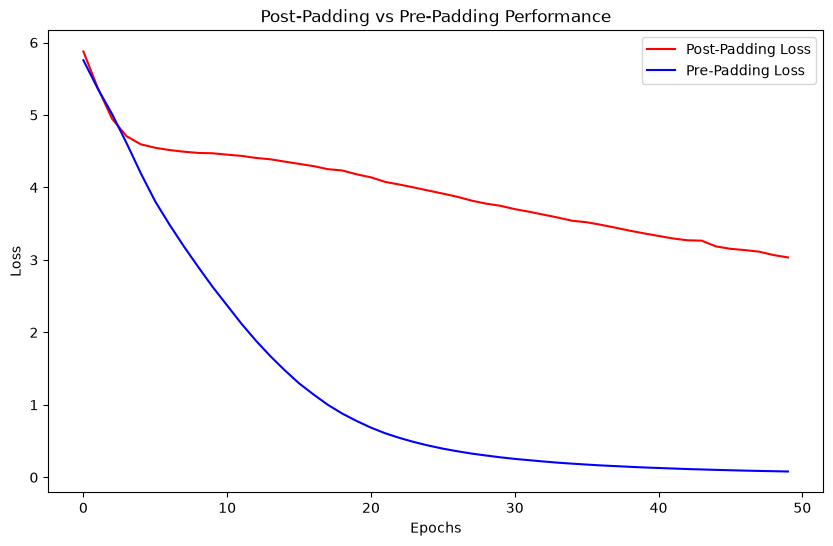

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(post_losses, label="Post-Padding Loss", color='red')
plt.plot(pre_losses, label="Pre-Padding Loss", color='blue')
plt.title("Post-Padding vs Pre-Padding Performance")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()